In [14]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import math 

### model prediction using vectorisation 

In [15]:
def predict(inputs,weights,bias):
    y = np.dot(inputs,weights) +bias
    return y 

### computing cost of parameters

In [16]:
def compute_cost(inputs,output,weights,bias):
    cost =0 
    m = inputs.shape[0]
    for i in range(m):
        cost += (predict(inputs[i],weights,bias)-output[i])**2
    cost /= 2 * m
    return cost 

In [17]:
def compute_gradients(inputs,outputs,weights,bias):
    m,n = inputs.shape
    dj_dw = np.zeros((n,))
    dj_db = 0 
    for i in range(m):
        err = (predict(inputs[i],weights,bias) - outputs[i])
        for j in range(n):
            dj_dw[j] += err * inputs[i,j]
        dj_db += err
    dj_dw /= m
    dj_db /= m
    return dj_dw,dj_db

In [18]:
def gradient_descent(inputs,outputs,weights_in,bias_in,alpha,iterations):
    j_hist = []
    weights = weights_in
    bias = bias_in
    for i in range(iterations):
        dj_dw,dj_db = compute_gradients(inputs, outputs, weights, bias)
        weights = weights - alpha* dj_dw
        bias = bias - alpha* dj_db
        if i<100000:      
            j_hist.append( compute_cost(inputs, outputs, weights, bias))

        if i% math.ceil(iterations / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_hist[-1]:8.2f}   ")
        
    return weights, bias, j_hist

In [19]:
def linear_regression(inputs,outputs,iterations=10000,alpha=0.01):
    m,n = inputs.shape
    intial_weights = np.zeros(n)
    intial_bias = 0.
    w_final, b_final, J_hist = gradient_descent(inputs, outputs, intial_weights, intial_bias, alpha, iterations)
    print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
    return w_final,b_final,J_hist
    

In [20]:
def train_test_split(x, y, test_size=0.25):
    
    # Shuffle indices
    shuffled_indices = x.sample(frac=1, random_state=42).index

    x = x.loc[shuffled_indices].reset_index(drop=True)
    y = y.loc[shuffled_indices].reset_index(drop=True)

    train_size = int((1 - test_size) * len(x))

    x_train = x.iloc[:train_size]
    x_test = x.iloc[train_size:]

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    return x_train, x_test, y_train, y_test

In [21]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [22]:
df = pd.read_csv("../Preprocessing/processed.csv")
x = df.drop(columns=['Weight'])
y = df['Weight']
x_scaled = (x - x.mean()) / x.std()
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y)

weight,bias,j_hist = linear_regression(x_scaled.values,y.values)
train_pred = predict(x_train,weight,bias)
test_pred = predict(x_test,weight,bias)

print(f"\nTrain R²  : {r_squared(y_train, train_pred):.4f}")
print(f"Test  R²  : {r_squared(y_test,  test_pred):.4f}")
print(f"Train RMSE: {rmse(y_train, train_pred):.4f} kg")
print(f"Test  RMSE: {rmse(y_test,  test_pred):.4f} kg")


Iteration    0: Cost  4010.26   
Iteration 1000: Cost   151.89   
Iteration 2000: Cost   151.86   
Iteration 3000: Cost   151.86   
Iteration 4000: Cost   151.86   
Iteration 5000: Cost   151.86   
Iteration 6000: Cost   151.86   
Iteration 7000: Cost   151.86   
Iteration 8000: Cost   151.86   
Iteration 9000: Cost   151.86   
b,w found by gradient descent: 86.58,[-1.67632209e+00  6.68562137e+00  1.10478416e+01  7.24871792e+00
  2.06713267e+00  4.25708094e+00 -9.92658564e-01  3.42044826e+00
 -2.96465861e-01  2.00570168e+00 -1.14927918e+00 -1.89730146e+00
 -1.11541033e+00  3.73957246e+00 -3.07912519e+00 -1.08981908e-01
 -5.74457445e-03  3.12250105e+00 -4.98040910e-01] 

Train R²  : 0.5571
Test  R²  : 0.5554
Train RMSE: 17.2677 kg
Test  RMSE: 17.8978 kg


In [23]:
print(train_pred,test_pred)

[ 74.80850025 103.43825698  88.37144149 ...  45.23856808 106.62741456
 108.88405758] [ 92.19728697 122.7487142   85.05555217  67.57482511 106.00447217
  84.39217671  86.94513175  77.71273286  89.04245302 102.92062001
 110.64315621  82.44306834  76.1400408   91.03634454  91.34235014
 104.62897884  80.14346813 104.94808732 104.6088062   82.92921025
  67.89580584  84.4551276   79.73261116  97.37666911  80.87111601
  88.41578589  89.77126996 105.58197725  99.83181292  83.94010912
  63.77094527  58.65681605  86.64788924  51.94108731 111.03496637
  77.64808964  48.82510955  60.97656358  59.85663478  97.69008199
  71.45348383  45.44303151  45.38271548  67.91886638  83.51655095
  78.31786655  39.92813199  91.73461633 115.23489405  99.150927
 101.25955007  59.36315955  83.51933627  89.90528581 116.64030117
  80.36484277  89.07334525 103.53155436  97.07897172  53.36046476
  94.99020129 105.70107556  87.87119541  99.04333259  86.54487097
 105.08945567 103.03420154  94.06469129  78.2609776   98.60

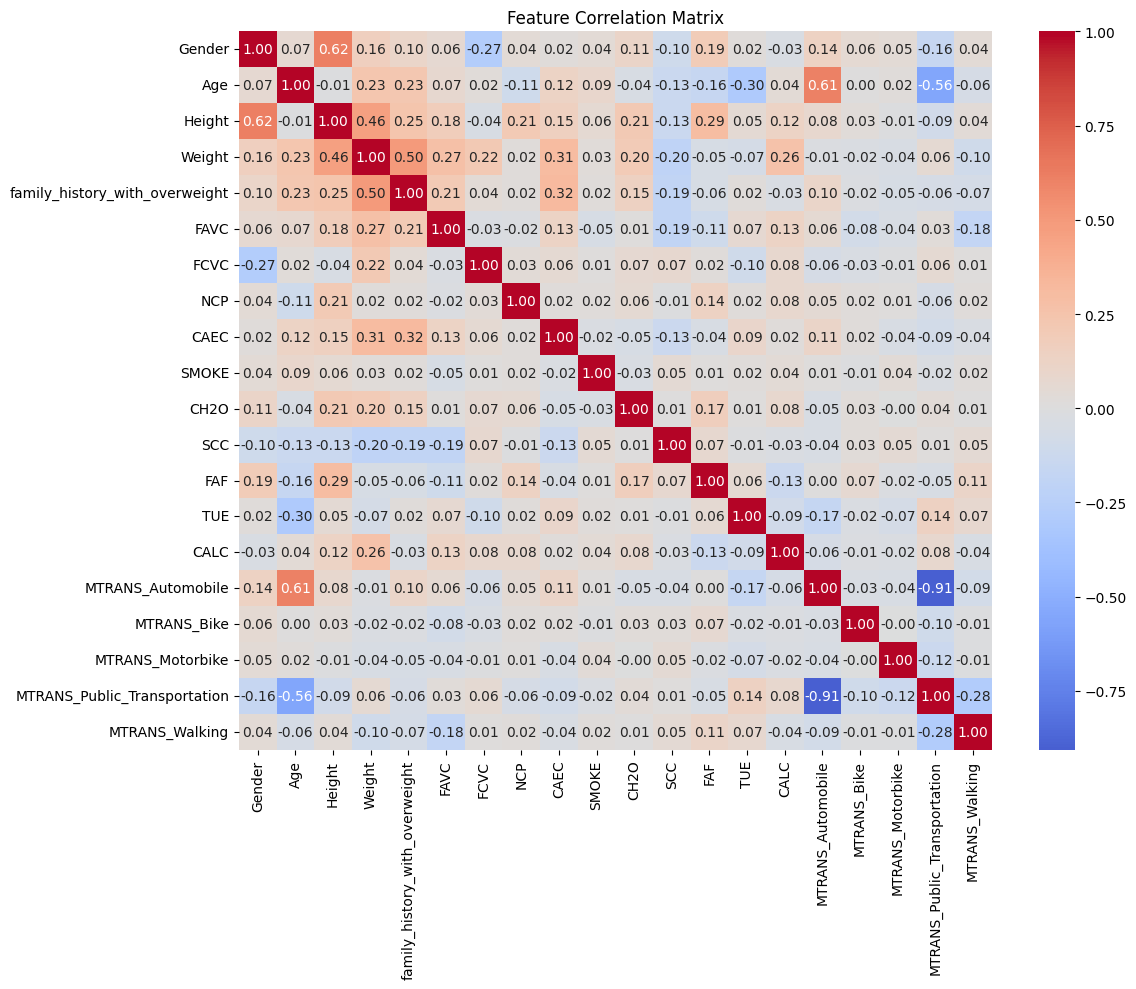

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

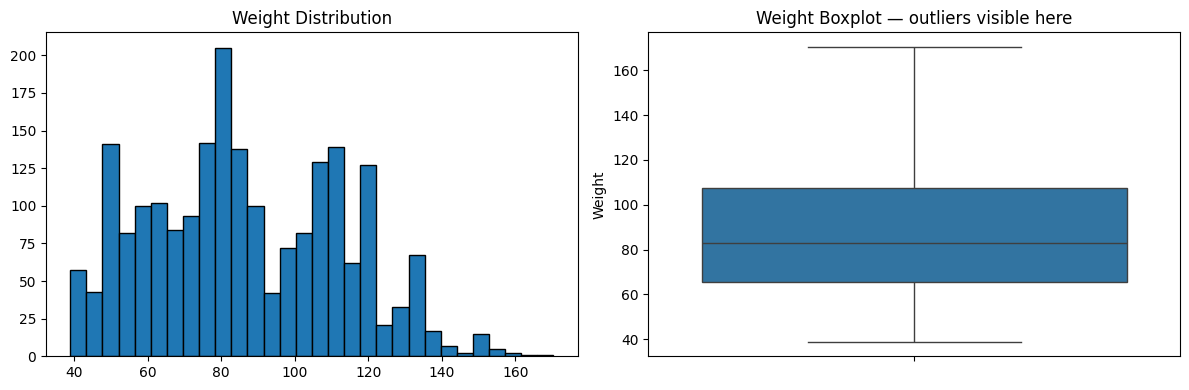

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Weight'], bins=30, edgecolor='black')
axes[0].set_title("Weight Distribution")
sns.boxplot(y=df['Weight'], ax=axes[1])
axes[1].set_title("Weight Boxplot — outliers visible here")
plt.tight_layout()
plt.show()
